Saving Titanic-Dataset.csv to Titanic-Dataset (3).csv
Shape: (891, 12)

First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            1

/tmp/ipykernel_5714/81882415.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_5714/81882415.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

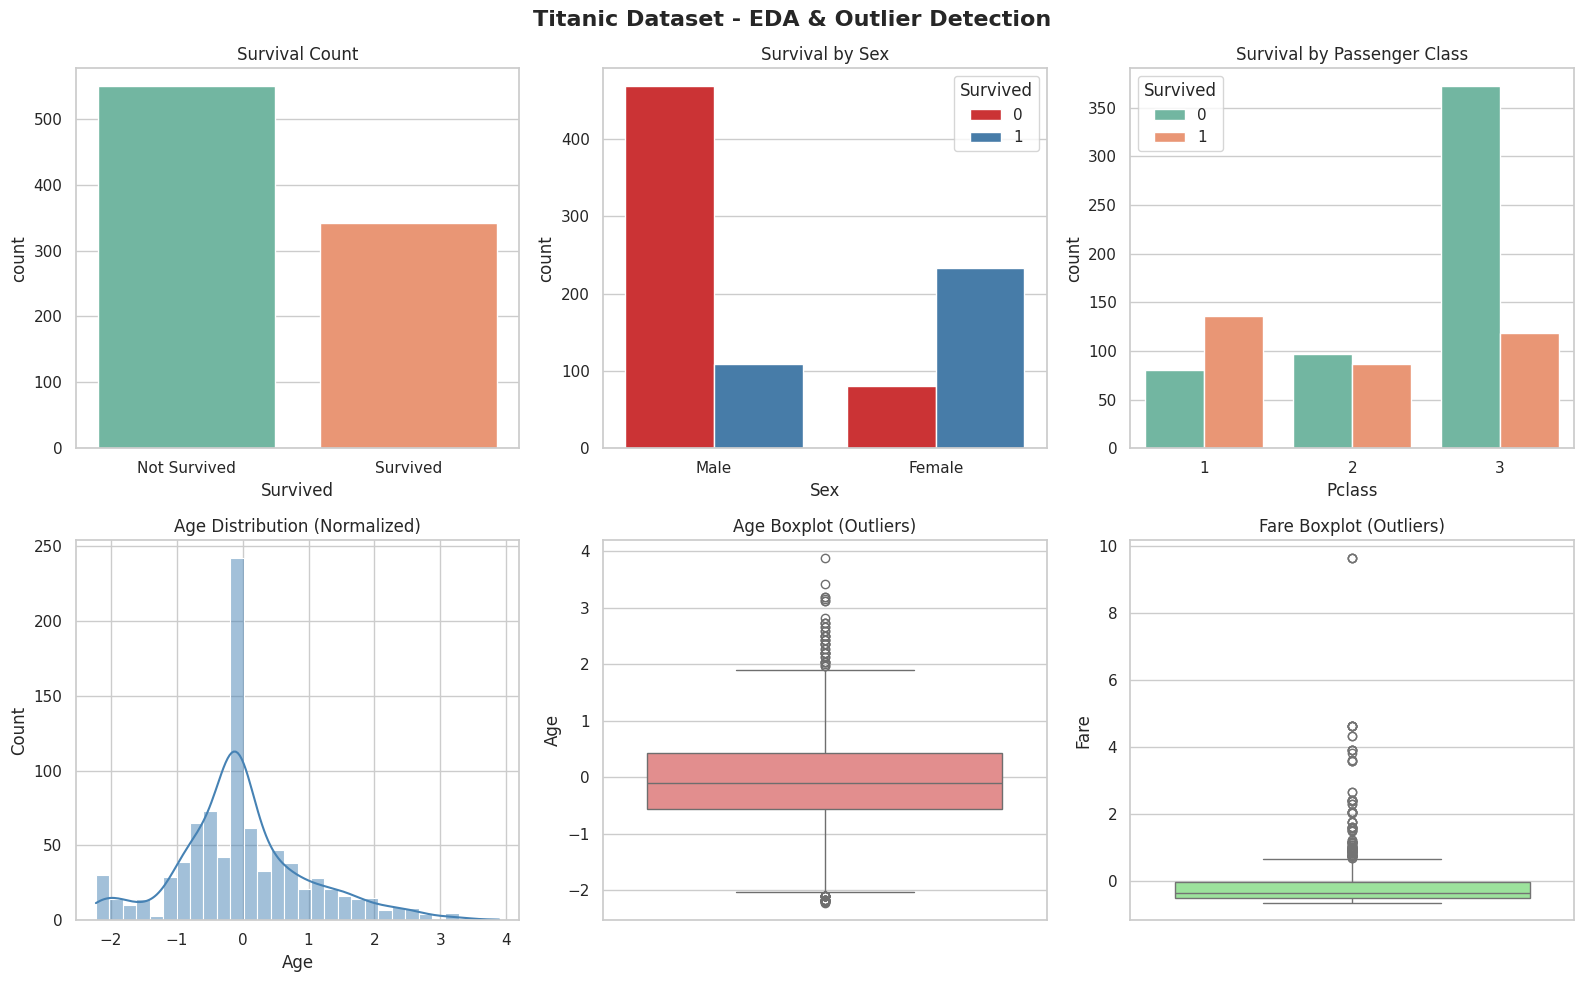


Plot saved as titanic_plots.png

Shape after outlier removal: (718, 9)

 Data Cleaning Complete!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. LOAD & EXPLORE
from google.colab import files
uploaded = files.upload()
import io
df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))
print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())


# 2. HANDLE MISSING VALUES
# Fill Age with median
df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill Embarked with mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin (too many nulls) and irrelevant columns
df.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"], inplace=True)

print("\nMissing values after cleaning:\n", df.isnull().sum())

# 3. ENCODE CATEGORICAL FEATURES
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)


# 4. NORMALIZE NUMERICAL FEATURES
scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])

print("\nCleaned Data Sample:\n", df.head())

# 5. VISUALIZATIONS
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Titanic Dataset - EDA & Outlier Detection", fontsize=16, fontweight="bold")

# Plot 1: Survival Count
sns.countplot(x="Survived", data=df, palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Survival Count")
axes[0, 0].set_xticklabels(["Not Survived", "Survived"])

# Plot 2: Survival by Sex
sns.countplot(x="Sex", hue="Survived", data=df, palette="Set1", ax=axes[0, 1])
axes[0, 1].set_title("Survival by Sex")
axes[0, 1].set_xticklabels(["Male", "Female"])

# Plot 3: Survival by Pclass
sns.countplot(x="Pclass", hue="Survived", data=df, palette="Set2", ax=axes[0, 2])
axes[0, 2].set_title("Survival by Passenger Class")

# Plot 4: Age Distribution
sns.histplot(df["Age"], kde=True, bins=30, color="steelblue", ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution (Normalized)")

# Plot 5: Boxplot of Age (outlier detection)
sns.boxplot(y="Age", data=df, color="lightcoral", ax=axes[1, 1])
axes[1, 1].set_title("Age Boxplot (Outliers)")

# Plot 6: Boxplot of Fare (outlier detection)
sns.boxplot(y="Fare", data=df, color="lightgreen", ax=axes[1, 2])
axes[1, 2].set_title("Fare Boxplot (Outliers)")

plt.tight_layout()
plt.savefig("titanic_plots.png", dpi=150)
plt.show()

# 6. REMOVE OUTLIERS (IQR Method)
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

df = remove_outliers(df, "Age")
df = remove_outliers(df, "Fare")

print(f"\nShape after outlier removal: {df.shape}")
print("\n Data Cleaning Complete!")